In [1]:
# Copyright (c) Meta Platforms, Inc. and affiliates.

# This source code is licensed under the MIT license found in the
# LICENSE file in the root directory of this source tree.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
res = pd.read_csv('Results_Syn/Simulation_Concept_Covariate_TLCQM_Mixture_Conditional_Mean.csv')
res = res[['Method', 'MSE', 'source_target_ratio', 'source_size', 'target_size']]

In [3]:
res['source_target_ratio'] = res['source_size'] / res['target_size']
res.groupby(['Method', 'source_target_ratio']).mean().reset_index().to_csv('./Tables/sim_mixture.csv', index=False)

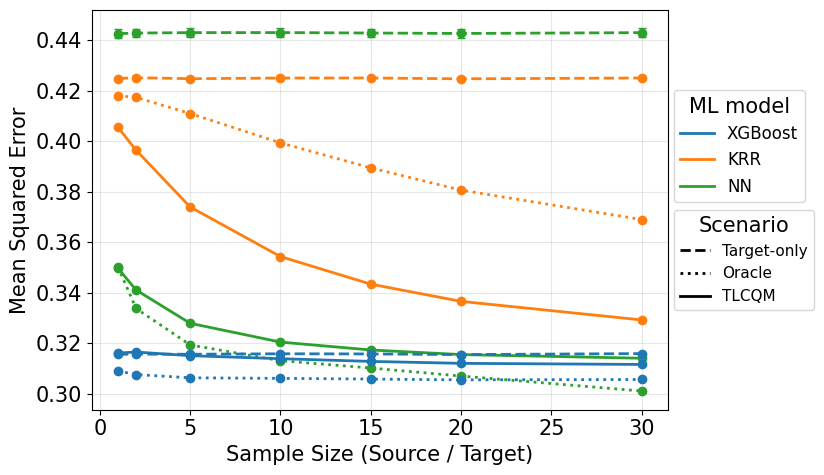

In [4]:
res['source_target_ratio'] = res['source_size'] / res['target_size']

from matplotlib.lines import Line2D
plt.rcParams.update({'font.size': 15})

summary = (
    res
    .groupby(["Method", "source_target_ratio"])
    .agg(
        mean_mse=("MSE", "mean"),
        se_mse=("MSE", lambda x: x.std(ddof=1) / np.sqrt(len(x)))
    )
    .reset_index()
)

# ---- parse Method into model + scenario ----
summary["Model"] = summary["Method"].str.split("_").str[0]
summary["Scenario"] = summary["Method"].str.split("_", n=1).str[1]

# ---- color & linestyle maps ----
color_map = {
    "XGBoost": "tab:blue",
    "KRR": "tab:orange",
    "NN": "tab:green"
}

linestyle_map = {
    "Target-only": "--",
    "Oracle": ":",
    "TLCQM": "-"
}

summary.loc[summary['Scenario'] == "Target_Only", "Scenario"] = "Target-only"

# ---- plot ----
fig, ax = plt.subplots(figsize=(8.5, 5))

for (model, scenario), sub in summary.groupby(["Model", "Scenario"]):
    ax.errorbar(
        sub["source_target_ratio"],
        sub["mean_mse"],
        yerr=sub["se_mse"],
        color=color_map[model],
        linestyle=linestyle_map[scenario],
        marker="o",
        linewidth=2,
        capsize=3
    )

# ---- legend handles ----
model_handles = [
    Line2D([0], [0], color=color_map[m], lw=2, label=m)
    for m in color_map
]

scenario_handles = [
    Line2D([0], [0], color="black", lw=2,
           linestyle=linestyle_map[s], label=s)
    for s in linestyle_map
]

# ---- place legends outside, stacked vertically ----
legend_model = ax.legend(
    handles=model_handles,
    title="ML model",
    loc="upper left",
    bbox_to_anchor=(1.01, 0.8),
    borderaxespad=0.0,
    fontsize=12
)

legend_scenario = ax.legend(
    handles=scenario_handles,
    title="Scenario",
    loc="upper left",
    bbox_to_anchor=(1.01, 0.5),
    borderaxespad=0.0,
    fontsize=11
)

ax.add_artist(legend_model)

# ---- labels & formatting ----
ax.set_xlabel("Sample Size (Source / Target)")
ax.set_ylabel("Mean Squared Error")
# ax.set_title("MSE vs Sample Size\n(Color = Model, Linestyle = Data Scenario)")
ax.grid(True, alpha=0.3)

plt.tight_layout()  # leave space for legends
plt.show()

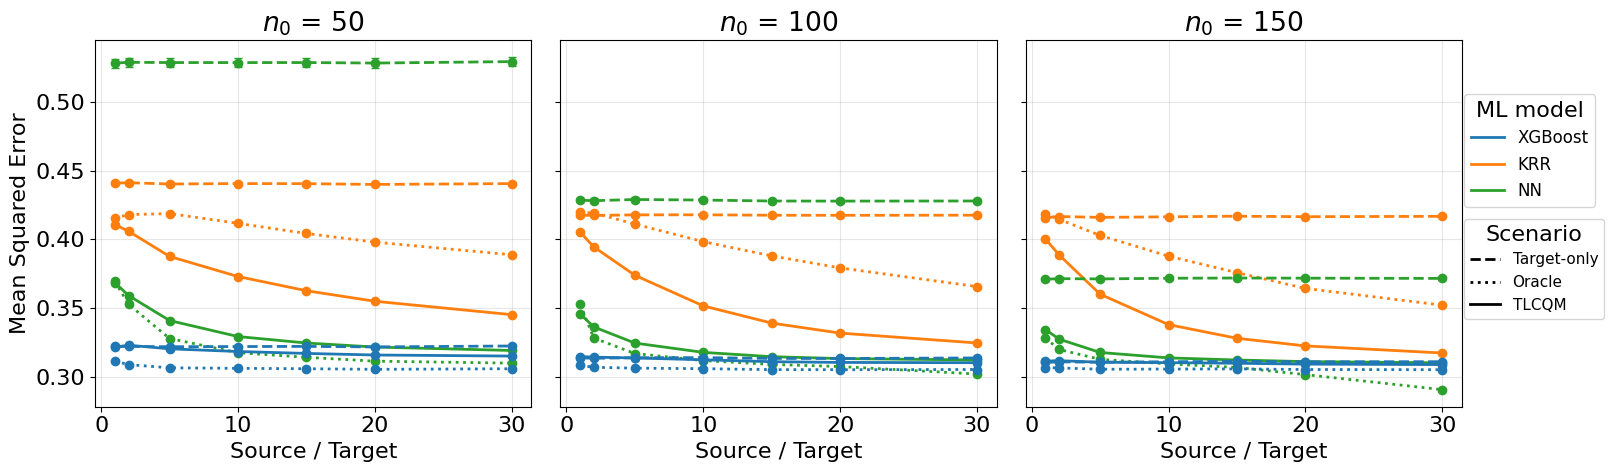

In [5]:
res['source_target_ratio'] = res['source_size'] / res['target_size']

from matplotlib.lines import Line2D
plt.rcParams.update({'font.size': 16})

# ---- recompute ratio ----
res["source_target_ratio"] = res["source_size"] / res["target_size"]

# ---- summary including target_size ----
summary = (
    res
    .groupby(["Method", "target_size", "source_target_ratio"])
    .agg(
        mean_mse=("MSE", "mean"),
        se_mse=("MSE", lambda x: x.std(ddof=1) / np.sqrt(len(x)))
    )
    .reset_index()
)

# ---- parse Method into model + scenario ----
summary["Model"] = summary["Method"].str.split("_").str[0]
summary["Scenario"] = summary["Method"].str.split("_", n=1).str[1]
summary.loc[summary["Scenario"] == "Target_Only", "Scenario"] = "Target-only"

# ---- color & linestyle maps ----
color_map = {
    "XGBoost": "tab:blue",
    "KRR": "tab:orange",
    "NN": "tab:green"
}

linestyle_map = {
    "Target-only": "--",
    "Oracle": ":",
    "TLCQM": "-"
}

# ---- create subplots ----
target_sizes = sorted(summary["target_size"].unique())
fig, axes = plt.subplots(
    1, len(target_sizes),
    figsize=(15, 5),
    sharey=True
)

# ---- plot each panel ----
for ax, tsize in zip(axes, target_sizes):
    sub_ts = summary[summary["target_size"] == tsize]

    for (model, scenario), sub in sub_ts.groupby(["Model", "Scenario"]):
        ax.errorbar(
            sub["source_target_ratio"],
            sub["mean_mse"],
            yerr=sub["se_mse"],
            color=color_map[model],
            linestyle=linestyle_map[scenario],
            marker="o",
            linewidth=2,
            capsize=3
        )

    ax.set_title(f"$n_0$ = {tsize}")
    ax.set_xlabel("Source / Target")
    ax.grid(True, alpha=0.3)

axes[0].set_ylabel("Mean Squared Error")

# ---- legends (shared, outside) ----
model_handles = [
    Line2D([0], [0], color=color_map[m], lw=2, label=m)
    for m in color_map
]

scenario_handles = [
    Line2D([0], [0], color="black", lw=2,
           linestyle=linestyle_map[s], label=s)
    for s in linestyle_map
]

legend_model = fig.legend(
    handles=model_handles,
    title="ML model",
    loc="upper left",
    bbox_to_anchor=(0.98, 0.8),
    fontsize=12
)

legend_scenario = fig.legend(
    handles=scenario_handles,
    title="Scenario",
    loc="upper left",
    bbox_to_anchor=(0.98, 0.55),
    fontsize=11
)

# ---- layout ----
plt.tight_layout()  # leave space for legends
plt.show()

In [6]:
res_comp = pd.read_csv('Results_Syn/Simulation_Concept_Covariate_TLCQM_Mixture_Compare.csv')
res_comp.groupby(['Method', 'source_size', 'target_size']).mean().reset_index().to_csv('./Tables/sim_comp_mixture.csv')

In [7]:
res = pd.read_csv('Results_Syn/Simulation_Concept_Covariate_TLCQM_Mixture_Conditional_Mean_Grid.csv')
res.groupby(['Method', 'source_size', 'target_size']).mean().reset_index().to_csv('./Tables/sim_mixture2.csv')

In [8]:
res_comp = pd.read_csv('Results_Syn/Simulation_Concept_Covariate_TLCQM_Mixture_Compare.csv')
res = pd.read_csv('Results_Syn/Simulation_Concept_Covariate_TLCQM_Mixture_Conditional_Mean_Grid.csv')

res_comp = res_comp.loc[res_comp['source_size'] != 100]
res = res.loc[res['source_size'] != 100]
res['Method1'] = res["Method"].str.split("_", n=1).str[1]
res_full = pd.concat([res_comp, res.loc[(res['Method1'] == 'TLCQM') & (res['source_size'] != 5000)]], axis=0)
# res_full = res_full.loc[(res_full['source_size'] == 200) | (res_full['source_size'] == 500) 
#                     | (res_full['source_size'] == 1000) | (res_full['source_size'] == 2000)]

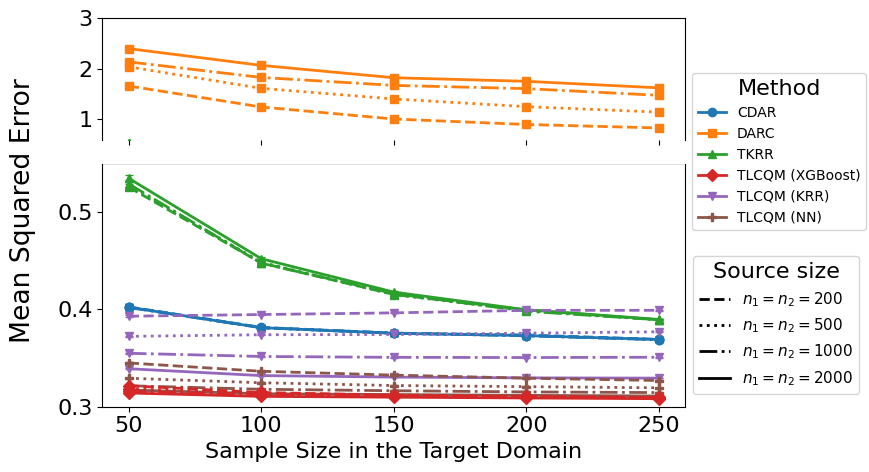

In [9]:
summary = (
    res_full.groupby(["Method", "source_size", "target_size"])["MSE"]
      .agg(mean="mean", sem="sem")
      .reset_index()
)
summary["Method"] = summary["Method"].str.replace(
    r"^(XGBoost|NN|KRR)_TLCQM$",
    r"TLCQM (\1)",
    regex=True
)

method_order = [
    "CDAR",
    "DARC",
    "TKRR",
    "TLCQM (XGBoost)",
    "TLCQM (KRR)",
    "TLCQM (NN)",
]
# Keep only methods listed in method_order
summary = summary[
    summary["Method"].isin(method_order)
].copy()

methods = [m for m in method_order if m in summary["Method"].unique()]
source_sizes = sorted(summary["source_size"].unique())

# Color by method
color_map = {
    m: plt.cm.tab10(i % 10)
    for i, m in enumerate(methods)
}

# Marker by method
markers = ["o", "s", "^", "D", "v", "P", "X", "*"]
marker_map = {
    m: markers[i % len(markers)]
    for i, m in enumerate(methods)
}

# Linestyle by source size
linestyles = ["--", ":", "-.", "-"]
linestyle_map = {
    s: linestyles[i % len(linestyles)]
    for i, s in enumerate(source_sizes)
}

fig, (ax_top, ax_bot) = plt.subplots(
    2, 1, sharex=True, figsize=(9, 5),
    gridspec_kw={"height_ratios": [1, 2]}
)

for (method, source_size), g in summary.groupby(["Method", "source_size"]):
    g = g.sort_values("target_size")

    for ax in (ax_top, ax_bot):
        ax.errorbar(
            g["target_size"],
            g["mean"],
            yerr=g["sem"],
            color=color_map[method],
            linestyle=linestyle_map[source_size],
            marker=marker_map[method],
            capsize=3,
            linewidth=2,
            markersize=6
        )

# Set y-limits manually
ax_top.set_ylim(0.6, 3)
ax_bot.set_ylim(0.3, 0.55)

# ---- hide spines at the junction ----
ax_top.spines["bottom"].set_visible(False)
ax_bot.spines["top"].set_visible(False)

ax_top.tick_params(labelbottom=False)
ax_bot.tick_params(top=False)

# ---- OPTIONAL: very light separator cue ----
ax_top.axhline(ax_top.get_ylim()[0], color="0.85", lw=0.6)
ax_bot.axhline(ax_bot.get_ylim()[1], color="0.85", lw=0.6)

ax_bot.set_xlabel("Sample Size in the Target Domain")

fig.subplots_adjust(right=0.72)

# --- Legend for Method (color) ---
method_handles = [
    Line2D(
        [0], [0],
        color=color_map[m],
        marker=marker_map[m],
        linestyle="-",
        lw=2,
        markersize=6,
        label=m
    )
    for m in methods
]

legend_method = ax.legend(
    handles=method_handles,
    title="Method",
    loc="upper left",
    bbox_to_anchor=(1, 1.4),
    frameon=True,
    fontsize=10
)
ax.add_artist(legend_method)

# --- Source size legend (linestyle only) ---
source_handles = [
    Line2D(
        [0], [0],
        color="black",
        linestyle=linestyle_map[s],
        lw=2,
        label=f"$n_1=n_2 =${s}",
    )
    for s in source_sizes
]

ax.legend(
    handles=source_handles,
    title="Source size",
    loc="upper left",
    bbox_to_anchor=(1, 0.65),
    frameon=True,
    fontsize=11
)

fig.supylabel("Mean Squared Error", x=0.03, y=0.55)
plt.tight_layout()
plt.show()

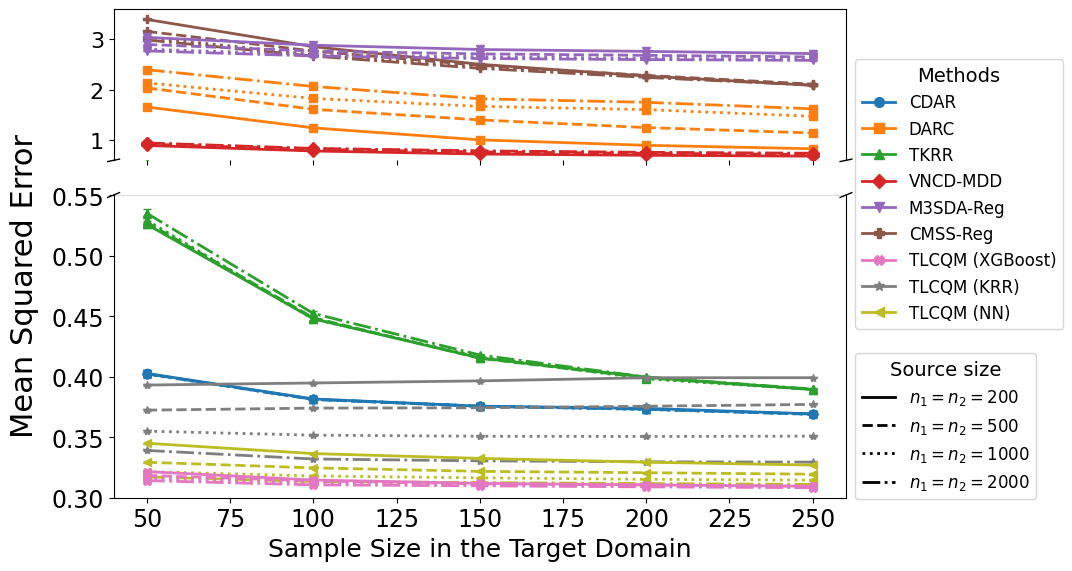

In [10]:
import matplotlib

summary = (
    res_full.groupby(["Method", "source_size", "target_size"])["MSE"]
      .agg(mean="mean", sem="sem")
      .reset_index()
)

# Rename TLCQM methods
summary["Method"] = summary["Method"].replace({
    "XGBoost_TLCQM": "TLCQM (XGBoost)",
    "KRR_TLCQM": "TLCQM (KRR)",
    "NN_TLCQM": "TLCQM (NN)",
    "VNCD_MDD": "VNCD-MDD",
    "M3SDA_Reg": "M3SDA-Reg",
    "CMSS_Reg": "CMSS-Reg",
})

method_order = [
    "CDAR",
    "DARC",
    "TKRR",
    "VNCD-MDD",
    "M3SDA-Reg",
    "CMSS-Reg",
    "TLCQM (XGBoost)",
    "TLCQM (KRR)",
    "TLCQM (NN)",
]

methods = [m for m in method_order if m in summary["Method"].unique()]
source_sizes = sorted(summary["source_size"].unique())

# Use a larger palette to improve separation
cmap = matplotlib.colormaps.get_cmap("tab10")
color_map = {m: cmap(i) for i, m in enumerate(methods)}

markers = ["o", "s", "^", "D", "v", "P", "X", "*", "<", ">"]
marker_map = {m: markers[i % len(markers)] for i, m in enumerate(methods)}

linestyles = ["-", "--", ":", "-."]
linestyle_map = {s: linestyles[i % len(linestyles)] for i, s in enumerate(source_sizes)}

fig, (ax_top, ax_bot) = plt.subplots(
    2, 1,
    sharex=True,
    figsize=(9, 6),
    gridspec_kw={"height_ratios": [1, 2]},
    constrained_layout=False
)

# leave a wider right margin for legends
fig.subplots_adjust(right=0.68, hspace=0.06)

for i, (method, source_size) in enumerate(summary.groupby(["Method", "source_size"]).groups.keys()):
    g = (
        summary[(summary["Method"] == method) & (summary["source_size"] == source_size)]
        .sort_values("target_size")
    )

    for ax in (ax_top, ax_bot):
        ax.errorbar(
            g["target_size"],
            g["mean"],
            yerr=g["sem"],
            color=color_map[method],
            linestyle=linestyle_map[source_size],
            marker=marker_map[method],
            capsize=3,
            linewidth=2,
            markersize=6,
            zorder=2 + i
        )

# y-axis ranges
ax_top.set_ylim(0.6, 3.6)
ax_bot.set_ylim(0.3, 0.55)

# set ticks manually
# ax_top.set_yticks([0.8, 1.5, 2.5])
# ax_bot.set_yticks([0.30, 0.32, 0.34, 0.36, 0.38, 0.5])

# broken-axis styling
ax_top.spines["bottom"].set_visible(False)
ax_bot.spines["top"].set_visible(False)
ax_top.tick_params(labelbottom=False)
ax_bot.tick_params(top=False)

# subtle separator lines
ax_top.axhline(ax_top.get_ylim()[0], color="0.85", lw=0.6)
ax_bot.axhline(ax_bot.get_ylim()[1], color="0.85", lw=0.6)

# optional diagonal break marks
d = 0.008
kwargs = dict(transform=ax_top.transAxes, color='k', clip_on=False, lw=1)
ax_top.plot((-d, +d), (-d, +d), **kwargs)
ax_top.plot((1 - d, 1 + d), (-d, +d), **kwargs)

kwargs.update(transform=ax_bot.transAxes)
ax_bot.plot((-d, +d), (1 - d, 1 + d), **kwargs)
ax_bot.plot((1 - d, 1 + d), (1 - d, 1 + d), **kwargs)

ax_bot.set_xlabel("Sample Size in the Target Domain", fontsize=18)
fig.supylabel("Mean Squared Error", x=0.04, fontsize=22)

# ---------- legends ----------
method_handles = [
    Line2D(
        [0], [0],
        color=color_map[m],
        marker=marker_map[m],
        linestyle="-",
        lw=2,
        markersize=7,
        label=m
    )
    for m in methods
]

source_handles = [
    Line2D(
        [0], [0],
        color="black",
        linestyle=linestyle_map[s],
        lw=2,
        label=fr"$n_1=n_2={s}$"
    )
    for s in source_sizes
]

# place legends separately in figure coordinates
fig.legend(
    handles=method_handles,
    title="Methods",
    loc="upper left",
    bbox_to_anchor=(0.97, 0.89),
    frameon=True,
    fontsize=12,
    title_fontsize=14
)

fig.legend(
    handles=source_handles,
    title="Source size",
    loc="upper left",
    bbox_to_anchor=(0.97, 0.4),
    frameon=True,
    fontsize=12,
    title_fontsize=14
)

# tick sizes
ax_top.tick_params(axis="y", labelsize=16)
ax_bot.tick_params(axis="both", labelsize=17)

plt.tight_layout()
plt.show()